# Fase 3 · Modelado predictivo

Construimos el modelo que predecirá la ocupación de cada estación de BiciMad **a 24 horas vista**, partiendo del dataset enriquecido de la fase 2.

Seguimos una **escalera progresiva**, validando cada nivel antes de subir:

1. **Baseline naive**: "la ocupación de mañana será la misma que la del mismo día de la semana, hace 7 días". Sin ML, solo una columna del dataset.
2. **Regresión lineal**: suelo razonable con un modelo simple.
3. **LightGBM**: gradient boosting, la apuesta principal.

En cada nivel medimos MAE y RMSE sobre el conjunto de validación temporal (octubre-diciembre 2022) y comparamos contra los anteriores.

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

ModuleNotFoundError: No module named 'sklearn'

In [2]:
RUTA = "df_entrenamiento.parquet"   # ajusta al nombre real de tu fichero

df = pd.read_parquet(RUTA)
print(f"Filas:    {len(df):,}")
print(f"Columnas: {len(df.columns)}")
print(f"Rango:    {df['hora'].min()} → {df['hora'].max()}")

Filas:    2,220,323
Columnas: 35
Rango:    2022-01-01 00:00:00 → 2022-12-31 23:00:00


In [3]:
fecha_corte = pd.Timestamp("2022-10-01")

df_train = df[df["hora"] < fecha_corte].copy()
df_val   = df[df["hora"] >= fecha_corte].copy()

print(f"Train: {len(df_train):,} filas  ({df_train['hora'].min()} → {df_train['hora'].max()})")
print(f"Val:   {len(df_val):,} filas  ({df_val['hora'].min()} → {df_val['hora'].max()})")
print(f"Ratio train: {len(df_train)/(len(df_train)+len(df_val))*100:.1f}%")

Train: 1,669,349 filas  (2022-01-01 00:00:00 → 2022-09-30 23:00:00)
Val:   550,974 filas  (2022-10-01 01:00:00 → 2022-12-31 23:00:00)
Ratio train: 75.2%


## Nivel 1: Baseline naive

El baseline más sensato para predicción a 24h vista es: **"la ocupación será igual a la que había a la misma hora y mismo día de la semana, hace 7 días"**. Esa columna ya existe en el dataset (`ocupation_lag_168h`), así que solo tenemos que compararla con la realidad.

### Métricas

- **MAE** (Mean Absolute Error): error medio absoluto. Como `ocupation` está en [0,1], un MAE de 0.10 significa "de media nos equivocamos en 10 puntos porcentuales".
- **RMSE** (Root Mean Squared Error): penaliza más los errores grandes.

Solo evaluamos sobre filas donde la realidad **y** la predicción están disponibles (los lags de la primera semana del año son NaN por construcción).

In [4]:
# Filtrar filas donde tanto la realidad como la predicción están disponibles
val_baseline = df_val.dropna(subset=["ocupation", "ocupation_lag_168h"])

y_real     = val_baseline["ocupation"]
y_baseline = val_baseline["ocupation_lag_168h"]

mae_baseline  = mean_absolute_error(y_real, y_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_real, y_baseline))

print(f"Baseline naive (predicción = ocupación misma hora, semana anterior)")
print(f"  Evaluado sobre {len(val_baseline):,} filas de validación")
print(f"  MAE:  {mae_baseline:.4f}  ({mae_baseline*100:.2f} puntos porcentuales)")
print(f"  RMSE: {rmse_baseline:.4f}")

Baseline naive (predicción = ocupación misma hora, semana anterior)
  Evaluado sobre 550,370 filas de validación
  MAE:  0.2170  (21.70 puntos porcentuales)
  RMSE: 0.2749


In [5]:
val_b2 = df_val.dropna(subset=["ocupation", "ocupation_media_7d"])

mae_media  = mean_absolute_error(val_b2["ocupation"], val_b2["ocupation_media_7d"])
rmse_media = np.sqrt(mean_squared_error(val_b2["ocupation"], val_b2["ocupation_media_7d"]))

print("Baseline 2: media móvil de 7 días")
print(f"  Evaluado sobre {len(val_b2):,} filas")
print(f"  MAE:  {mae_media:.4f}  ({mae_media*100:.2f} puntos porcentuales)")
print(f"  RMSE: {rmse_media:.4f}")

print(f"\nComparativa de baselines:")
print(f"  Lag 168h:      MAE = {mae_baseline:.4f}  | RMSE = {rmse_baseline:.4f}")
print(f"  Media 7 días:  MAE = {mae_media:.4f}  | RMSE = {rmse_media:.4f}")

Baseline 2: media móvil de 7 días
  Evaluado sobre 550,744 filas
  MAE:  0.1816  (18.16 puntos porcentuales)
  RMSE: 0.2242

Comparativa de baselines:
  Lag 168h:      MAE = 0.2170  | RMSE = 0.2749
  Media 7 días:  MAE = 0.1816  | RMSE = 0.2242


## Análisis de los baselines

### Resultados

| Baseline | MAE | RMSE |
|---|---|---|
| **Lag 168h** (misma hora, hace 7 días) | 0.2170 | 0.2749 |
| **Media móvil 7 días** (promedio de la misma hora en la semana anterior) | **0.1816** | **0.2242** |

### Lectura de los números

Como `ocupation` está en el rango [0, 1], un MAE de 0.18 significa que el baseline **se equivoca de media en 18 puntos porcentuales** al predecir la ocupación de cada estación-hora. El RMSE, al ser bastante mayor que el MAE, indica que hay errores grandes mezclados con errores pequeños (la varianza del error no es uniforme).

### Por qué la media móvil bate al lag puntual

El lag de 168h dice *"predigo lo mismo que pasó en ese mismo momento hace una semana"*. Si la semana pasada hubo algo anómalo (lluvia, evento, festivo, error de medición), el baseline se equivoca de pleno.

La media móvil de 7 días dice *"predigo el promedio de lo que pasó en los últimos 7 días en esa misma estación a esa misma hora"*. Si la semana pasada hubo un día raro, queda **diluido** entre los demás. Es el principio clásico del **suavizado**: pierdes señal puntual pero ganas robustez frente al ruido.

La media bate al lag puntual en **4 puntos porcentuales de MAE** (0.1816 frente a 0.2170), una mejora del **16%**. Y este resultado, aún sin tocar ningún modelo de ML, ya nos da una pista valiosa: **las features de tendencia reciente van a pesar mucho en el modelo final**.

### El termómetro del proyecto

A partir de aquí, todo modelo que probemos debe **batir claramente el MAE de 0.1816**. Si lo bate, aporta valor real más allá de un cálculo trivial. Si no lo bate, hay algo mal diseñado.

- Una regresión lineal razonable debería bajar el MAE hasta el rango **0.12 - 0.15**.
- Un LightGBM bien ajustado debería bajarlo a **0.08 - 0.11**, casi a la mitad del baseline.

### Para la defensa

> *"El proyecto define dos baselines naive como termómetro: uno puntual (lag de 168 horas) y otro suavizado (media móvil de 7 días). Compararlos demuestra que las features de tendencia agregada aportan más valor que las puntuales, lo que ya valida la utilidad de la ingeniería de variables construida en la fase 2. Todo modelo posterior debe batir al baseline más exigente (MAE = 0.1816 sobre el conjunto de validación octubre-diciembre 2022) para justificar su existencia."*

## Nivel 2: Regresión lineal

Entrenamos una **regresión lineal** que use todas las features construidas: lags, medias móviles, calendario, meteorología y POIs.

### Por qué este modelo

La regresión lineal es el modelo más simple que aprovecha **todas las variables a la vez**. Le entrenas con los datos de enero-septiembre y le pides que ajuste un coeficiente para cada feature, de forma que la suma ponderada se acerque a la ocupación real.

### Qué esperar

Una regresión lineal **no captura interacciones no lineales** (por ejemplo, "esta estación se vacía solo si llueve Y es laborable Y es mañana"). Por eso esperamos que mejore al baseline, pero no por mucho. Si te bate al baseline, las features tienen información útil. Si no, hay algo mal.

In [6]:
# Variables que entran al modelo (todas menos las identificativas y el target)
FEATURES = [
    # Calendario
    "hora_dia", "dia_semana", "mes", "es_finde", "es_festivo",
    # Lags y medias móviles
    "ocupation_lag_24h", "ocupation_lag_168h", "ocupation_media_7d",
    "salidas_lag_24h", "salidas_lag_168h", "salidas_media_24h",
    "entradas_lag_24h", "entradas_lag_168h", "entradas_media_24h",
    # Meteorología
    "temperatura", "precipitacion", "viento",
    # POIs (estáticos por estación)
    "oficinas", "restaurantes_bares", "comercio", "educacion",
    "transporte", "deporte", "ocio",
    # Capacidad
    "total_bases",
]
TARGET = "ocupation"

# Filtrar filas que tengan TODAS las features y el target disponibles
df_train_clean = df_train.dropna(subset=FEATURES + [TARGET])
df_val_clean   = df_val.dropna(subset=FEATURES + [TARGET])

print(f"Filas de train limpias: {len(df_train_clean):,}")
print(f"Filas de val limpias:   {len(df_val_clean):,}")
print(f"Features utilizadas: {len(FEATURES)}")

Filas de train limpias: 1,623,708
Filas de val limpias:   550,149
Features utilizadas: 25


In [7]:
from sklearn.linear_model import LinearRegression

X_train = df_train_clean[FEATURES]
y_train = df_train_clean[TARGET]
X_val   = df_val_clean[FEATURES]
y_val   = df_val_clean[TARGET]

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado.")
print(f"Intercepto: {modelo.intercept_:.4f}")
print(f"Nº de coeficientes: {len(modelo.coef_)}")

Modelo entrenado.
Intercepto: 0.1144
Nº de coeficientes: 25


In [8]:
y_pred = modelo.predict(X_val)

mae_rl  = mean_absolute_error(y_val, y_pred)
rmse_rl = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"Regresión lineal")
print(f"  Evaluado sobre {len(y_val):,} filas")
print(f"  MAE:  {mae_rl:.4f}  ({mae_rl*100:.2f} puntos porcentuales)")
print(f"  RMSE: {rmse_rl:.4f}")

print(f"\nComparativa completa:")
print(f"  Baseline 1 (lag 168h):     MAE = {mae_baseline:.4f}  | RMSE = {rmse_baseline:.4f}")
print(f"  Baseline 2 (media 7 días): MAE = {mae_media:.4f}  | RMSE = {rmse_media:.4f}")
print(f"  Regresión lineal:          MAE = {mae_rl:.4f}  | RMSE = {rmse_rl:.4f}")

# Mejora porcentual
print(f"\nMejora vs baseline más exigente (media 7 días):")
print(f"  Reducción de MAE:  {(1 - mae_rl/mae_media)*100:+.1f}%")
print(f"  Reducción de RMSE: {(1 - rmse_rl/rmse_media)*100:+.1f}%")

Regresión lineal
  Evaluado sobre 550,149 filas
  MAE:  0.1651  (16.51 puntos porcentuales)
  RMSE: 0.2048

Comparativa completa:
  Baseline 1 (lag 168h):     MAE = 0.2170  | RMSE = 0.2749
  Baseline 2 (media 7 días): MAE = 0.1816  | RMSE = 0.2242
  Regresión lineal:          MAE = 0.1651  | RMSE = 0.2048

Mejora vs baseline más exigente (media 7 días):
  Reducción de MAE:  +9.1%
  Reducción de RMSE: +8.7%


## Nivel 3: LightGBM

Pasamos al modelo que va a marcar la diferencia: **LightGBM** (gradient boosting). Construye cientos de árboles de decisión pequeños donde cada uno aprende a corregir los errores del anterior. Resultado: captura **interacciones no lineales** y efectos complejos que la regresión lineal no puede ver.

### Por qué LightGBM y no otro

- **Rápido y eficiente** con datos tabulares de millones de filas.
- **Admite NaN sin necesidad de imputar** (importante para los lags iniciales del año).
- **Da importancia de variables** automáticamente: sabremos qué pesa más.
- **Estado del arte** para este tipo de problemas (regresión tabular).

### Configuración inicial

Usamos parámetros razonables por defecto. Más adelante podríamos optimizar hiperparámetros (learning rate, profundidad, regularización...), pero primero queremos ver de qué es capaz "sin esforzarse".

In [10]:
import lightgbm as lgb

# Usamos los df originales, no los "clean": LightGBM admite NaN
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_val   = df_val[FEATURES]
y_val   = df_val[TARGET]

# Filtramos solo las filas donde el target NO es NaN (es lo único imprescindible)
mask_train = y_train.notna()
mask_val   = y_val.notna()

X_train, y_train = X_train[mask_train], y_train[mask_train]
X_val,   y_val   = X_val[mask_val],   y_val[mask_val]

print(f"Filas de train: {len(X_train):,}")
print(f"Filas de val:   {len(X_val):,}")

# Crear datasets para LightGBM
dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_val,   label=y_val, reference=dtrain)

# Parámetros del modelo
params = {
    "objective":      "regression",
    "metric":         "mae",
    "learning_rate":  0.05,
    "num_leaves":     63,
    "max_depth":      -1,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq":   5,
    "verbose":        -1,
    "seed":           42,
}

# Entrenar con early stopping (para si el modelo deja de mejorar)
print("\nEntrenando LightGBM (puede tardar 1-3 minutos)...")
modelo_lgb = lgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dval],
    valid_names=["train", "val"],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)

print(f"\n✓ Modelo entrenado con {modelo_lgb.best_iteration} iteraciones")

Filas de train: 1,668,781
Filas de val:   550,744

Entrenando LightGBM (puede tardar 1-3 minutos)...
Training until validation scores don't improve for 50 rounds
[100]	train's l1: 0.164808	val's l1: 0.160584
[200]	train's l1: 0.161453	val's l1: 0.158659
[300]	train's l1: 0.15948	val's l1: 0.157767
[400]	train's l1: 0.157913	val's l1: 0.157377
[500]	train's l1: 0.15648	val's l1: 0.157031
[600]	train's l1: 0.155305	val's l1: 0.156793
[700]	train's l1: 0.154147	val's l1: 0.156629
[800]	train's l1: 0.153017	val's l1: 0.156385
[900]	train's l1: 0.152122	val's l1: 0.156248
[1000]	train's l1: 0.151186	val's l1: 0.156128
Did not meet early stopping. Best iteration is:
[1000]	train's l1: 0.151186	val's l1: 0.156128

✓ Modelo entrenado con 1000 iteraciones


In [11]:
import lightgbm as lgb

# Parámetros un pelín más generosos
params = {
    "objective":      "regression",
    "metric":         "mae",
    "learning_rate":  0.05,
    "num_leaves":     63,
    "max_depth":      -1,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq":   5,
    "verbose":        -1,
    "seed":           42,
}

print("Reentrenando LightGBM con más iteraciones...")
modelo_lgb = lgb.train(
    params,
    dtrain,
    num_boost_round=5000,             # subimos de 1000 a 5000
    valid_sets=[dtrain, dval],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),   # más paciencia
        lgb.log_evaluation(period=200)
    ],
)

print(f"\n✓ Modelo entrenado con {modelo_lgb.best_iteration} iteraciones")

Reentrenando LightGBM con más iteraciones...
Training until validation scores don't improve for 100 rounds
[200]	train's l1: 0.161453	val's l1: 0.158659
[400]	train's l1: 0.157913	val's l1: 0.157377
[600]	train's l1: 0.155305	val's l1: 0.156793
[800]	train's l1: 0.153017	val's l1: 0.156385
[1000]	train's l1: 0.151186	val's l1: 0.156128
[1200]	train's l1: 0.149436	val's l1: 0.155928
[1400]	train's l1: 0.147841	val's l1: 0.155815
Early stopping, best iteration is:
[1374]	train's l1: 0.148018	val's l1: 0.155797

✓ Modelo entrenado con 1374 iteraciones


In [12]:
y_pred = modelo_lgb.predict(X_val, num_iteration=modelo_lgb.best_iteration)

mae_lgb  = mean_absolute_error(y_val, y_pred)
rmse_lgb = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"LightGBM")
print(f"  Evaluado sobre {len(y_val):,} filas")
print(f"  MAE:  {mae_lgb:.4f}  ({mae_lgb*100:.2f} puntos porcentuales)")
print(f"  RMSE: {rmse_lgb:.4f}")

print(f"\nComparativa completa:")
print(f"  Baseline 1 (lag 168h):     MAE = {mae_baseline:.4f}")
print(f"  Baseline 2 (media 7 días): MAE = {mae_media:.4f}")
print(f"  Regresión lineal:          MAE = {mae_rl:.4f}")
print(f"  LightGBM:                  MAE = {mae_lgb:.4f}")

print(f"\nMejora vs baseline más exigente (media 7 días):")
print(f"  Reducción de MAE:  {(1 - mae_lgb/mae_media)*100:+.1f}%")
print(f"  Reducción vs regresión lineal: {(1 - mae_lgb/mae_rl)*100:+.1f}%")

LightGBM
  Evaluado sobre 550,744 filas
  MAE:  0.1558  (15.58 puntos porcentuales)
  RMSE: 0.1942

Comparativa completa:
  Baseline 1 (lag 168h):     MAE = 0.2170
  Baseline 2 (media 7 días): MAE = 0.1816
  Regresión lineal:          MAE = 0.1651
  LightGBM:                  MAE = 0.1558

Mejora vs baseline más exigente (media 7 días):
  Reducción de MAE:  +14.2%
  Reducción vs regresión lineal: +5.6%


Importancia de variables (Top 25):
               feature  pct_gain  pct_split
0    ocupation_lag_24h     53.96       6.26
1   ocupation_lag_168h      9.12       5.66
2   ocupation_media_7d      7.66      12.24
3             hora_dia      4.29       6.24
4           dia_semana      3.99       7.97
5             comercio      2.92       7.07
6   restaurantes_bares      2.89       6.98
7             oficinas      1.89       4.88
8           transporte      1.89       5.46
9   entradas_media_24h      1.88       6.33
10                 mes      1.75       5.29
11   salidas_media_24h      1.58       5.89
12         temperatura      1.32       5.00
13           educacion      0.80       2.33
14                ocio      0.65       1.98
15             deporte      0.60       1.55
16              viento      0.53       2.93
17         total_bases      0.52       1.50
18   entradas_lag_168h      0.46       0.89
19       precipitacion      0.30       0.87
20          es_festivo      0.25       0.

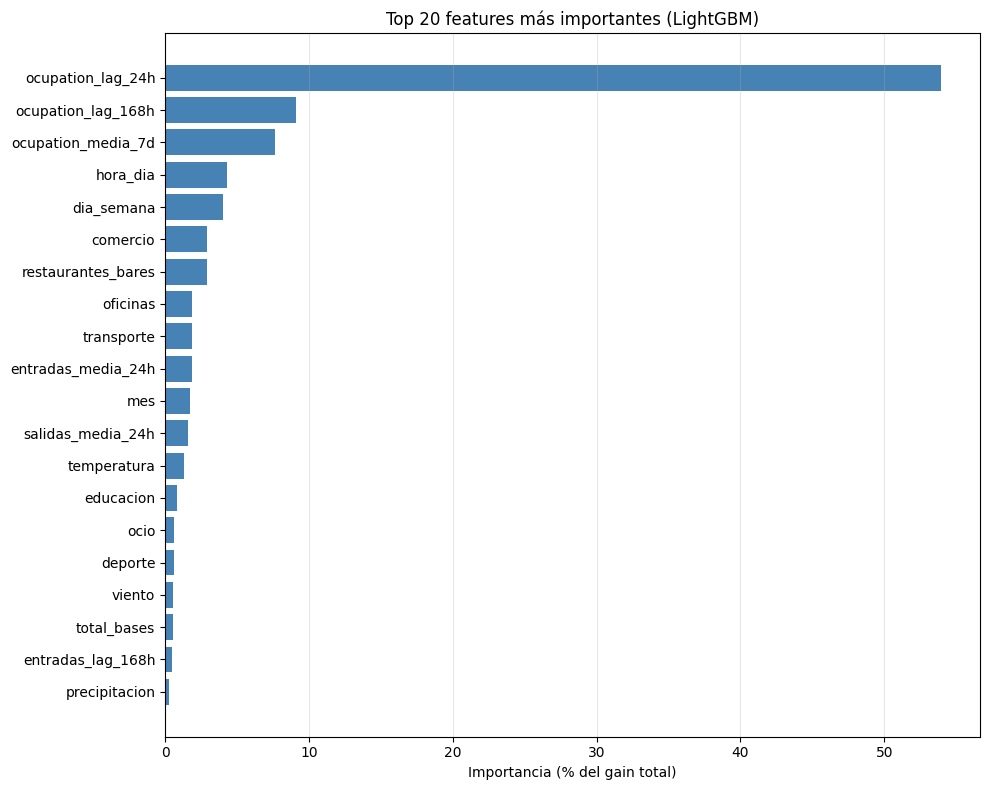

In [13]:
import matplotlib.pyplot as plt

# Extraer importancia
importance = pd.DataFrame({
    "feature": modelo_lgb.feature_name(),
    "importance_gain":  modelo_lgb.feature_importance(importance_type="gain"),
    "importance_split": modelo_lgb.feature_importance(importance_type="split"),
}).sort_values("importance_gain", ascending=False).reset_index(drop=True)

# Normalizar para que sumen 100
importance["pct_gain"]  = importance["importance_gain"]  / importance["importance_gain"].sum()  * 100
importance["pct_split"] = importance["importance_split"] / importance["importance_split"].sum() * 100

print("Importancia de variables (Top 25):")
print(importance[["feature", "pct_gain", "pct_split"]].head(25).round(2))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 8))
top = importance.head(20)
ax.barh(top["feature"][::-1], top["pct_gain"][::-1], color="steelblue")
ax.set_xlabel("Importancia (% del gain total)")
ax.set_title("Top 20 features más importantes (LightGBM)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

Estadísticas del error absoluto:
count    550744.0000
mean          0.1558
std           0.1159
min           0.0000
25%           0.0642
50%           0.1335
75%           0.2224
max           0.8878
Name: error_abs, dtype: float64

Percentil 95: 0.3784
Percentil 99: 0.5021


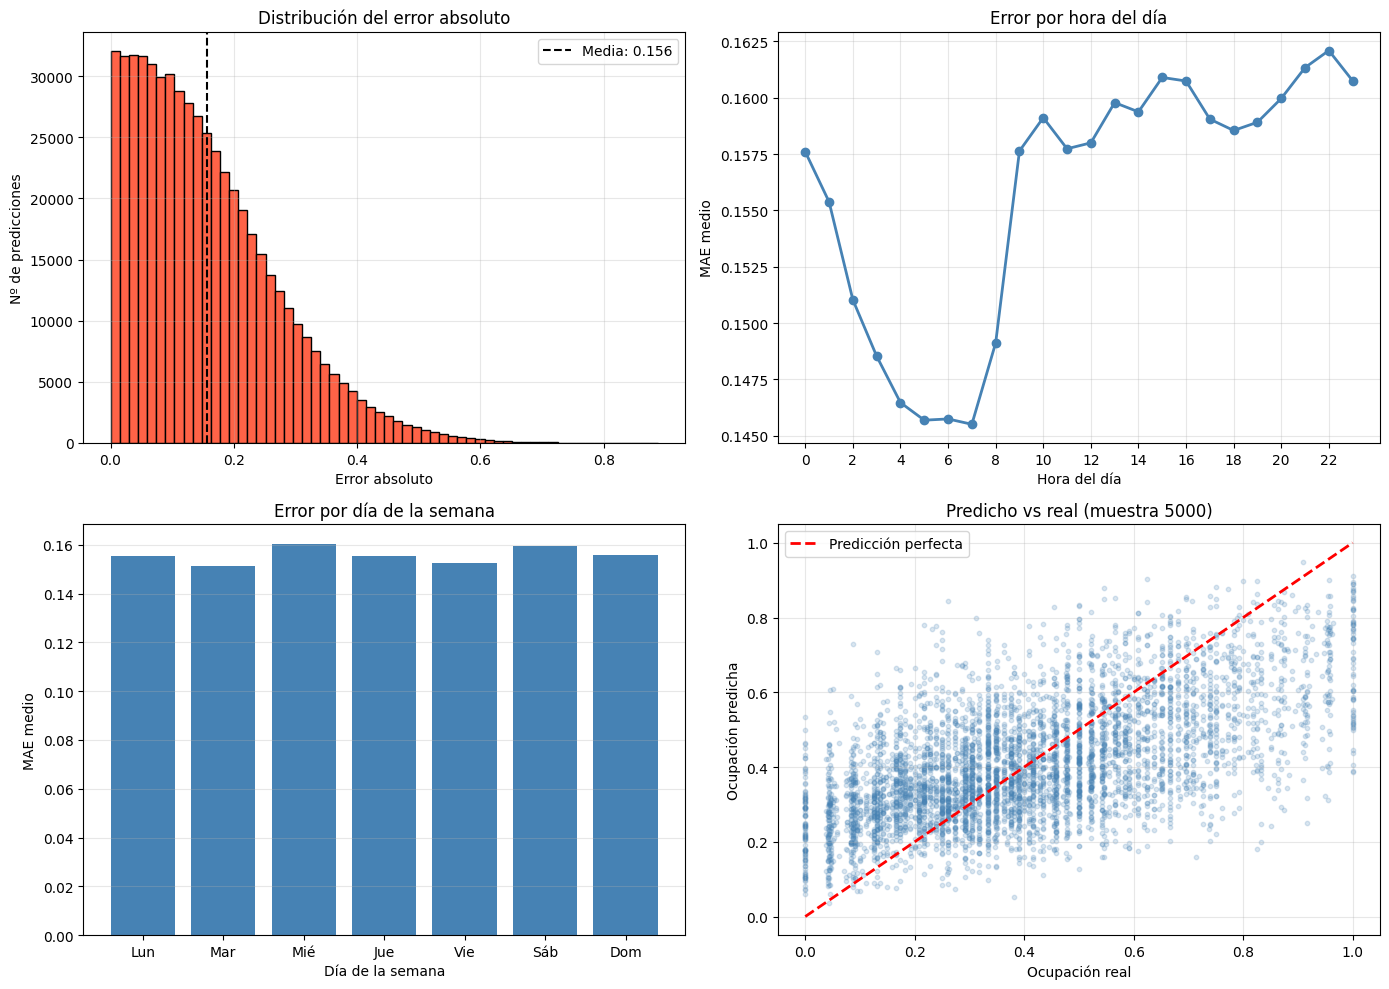


5 peores predicciones:
                       hora                   name  ocupation      pred  error_abs  temperatura  es_festivo
321035  2022-10-05 20:00:00     Plaza de la Cebada   0.000000  0.887801   0.887801         26.1       False
1168471 2022-10-05 21:00:00  Paseo de la Habana 42   1.000000  0.126227   0.873773         25.0       False
322928  2022-12-24 22:00:00     Plaza de la Cebada   0.000000  0.830271   0.830271          9.4       False
347133  2022-10-14 00:00:00           Santa Isabel   0.055556  0.874900   0.819345         15.8       False
346847  2022-10-01 22:00:00           Santa Isabel   0.000000  0.818469   0.818469         18.4       False


In [14]:
import matplotlib.pyplot as plt

# Construir un dataframe con predicciones y errores
df_errores = df_val[mask_val].copy()
df_errores["pred"] = y_pred
df_errores["error"] = df_errores["ocupation"] - df_errores["pred"]
df_errores["error_abs"] = df_errores["error"].abs()

print(f"Estadísticas del error absoluto:")
print(df_errores["error_abs"].describe().round(4))
print(f"\nPercentil 95: {df_errores['error_abs'].quantile(0.95):.4f}")
print(f"Percentil 99: {df_errores['error_abs'].quantile(0.99):.4f}")

# Cuatro gráficos en una sola figura
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Distribución del error absoluto
axes[0,0].hist(df_errores["error_abs"], bins=60, color="tomato", edgecolor="black")
axes[0,0].axvline(df_errores["error_abs"].mean(), color="black", linestyle="--", label=f'Media: {df_errores["error_abs"].mean():.3f}')
axes[0,0].set_xlabel("Error absoluto")
axes[0,0].set_ylabel("Nº de predicciones")
axes[0,0].set_title("Distribución del error absoluto")
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# 2) Error por hora del día
err_por_hora = df_errores.groupby("hora_dia")["error_abs"].mean()
axes[0,1].plot(err_por_hora.index, err_por_hora.values, marker="o", color="steelblue", linewidth=2)
axes[0,1].set_xlabel("Hora del día")
axes[0,1].set_ylabel("MAE medio")
axes[0,1].set_title("Error por hora del día")
axes[0,1].set_xticks(range(0, 24, 2))
axes[0,1].grid(alpha=0.3)

# 3) Error por día de la semana
err_por_dia = df_errores.groupby("dia_semana")["error_abs"].mean()
labels = ["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"]
axes[1,0].bar(labels, err_por_dia.values, color="steelblue")
axes[1,0].set_xlabel("Día de la semana")
axes[1,0].set_ylabel("MAE medio")
axes[1,0].set_title("Error por día de la semana")
axes[1,0].grid(alpha=0.3, axis="y")

# 4) Predicho vs real (scatter con muestra)
sample = df_errores.sample(5000, random_state=42)
axes[1,1].scatter(sample["ocupation"], sample["pred"], alpha=0.2, s=10, color="steelblue")
axes[1,1].plot([0,1], [0,1], "r--", linewidth=2, label="Predicción perfecta")
axes[1,1].set_xlabel("Ocupación real")
axes[1,1].set_ylabel("Ocupación predicha")
axes[1,1].set_title("Predicho vs real (muestra 5000)")
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Top 5 errores más grandes
print(f"\n5 peores predicciones:")
print(df_errores.nlargest(5, "error_abs")[["hora","name","ocupation","pred","error_abs","temperatura","es_festivo"]].to_string())

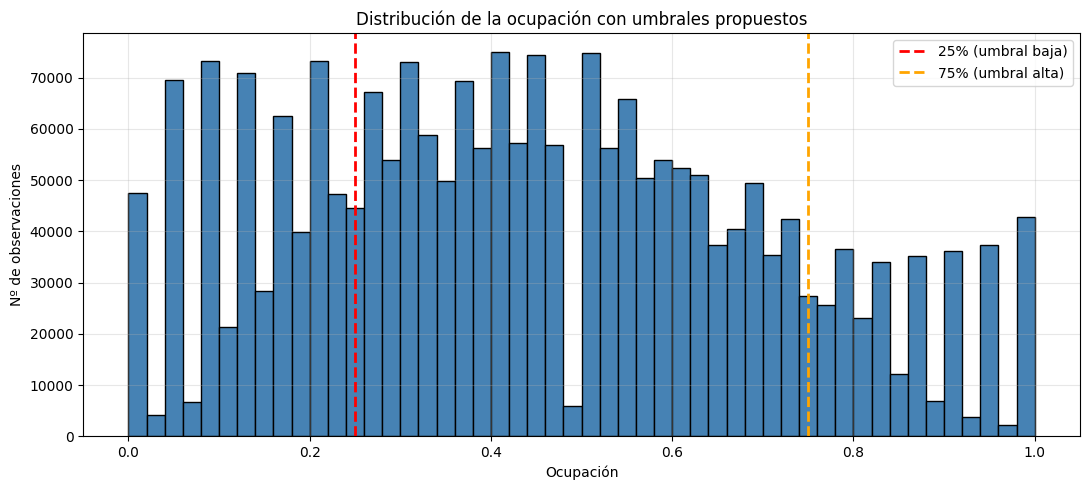


Distribución con umbrales 25%/75%:
  BAJA  (<25%):      24.6%  →  546,671 observaciones
  NORMAL (25-75%):   62.0%  →  1,377,105 observaciones
  ALTA  (>75%):      13.3%  →  295,749 observaciones


In [15]:
import matplotlib.pyplot as plt

# Distribución completa de la ocupación
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df["ocupation"].dropna(), bins=50, color="steelblue", edgecolor="black")
ax.axvline(0.25, color="red", linestyle="--", linewidth=2, label="25% (umbral baja)")
ax.axvline(0.75, color="orange", linestyle="--", linewidth=2, label="75% (umbral alta)")
ax.set_xlabel("Ocupación")
ax.set_ylabel("Nº de observaciones")
ax.set_title("Distribución de la ocupación con umbrales propuestos")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Porcentajes en cada categoría
total = df["ocupation"].notna().sum()
baja   = (df["ocupation"] < 0.25).sum() / total * 100
normal = ((df["ocupation"] >= 0.25) & (df["ocupation"] <= 0.75)).sum() / total * 100
alta   = (df["ocupation"] > 0.75).sum() / total * 100
print(f"\nDistribución con umbrales 25%/75%:")
print(f"  BAJA  (<25%):     {baja:5.1f}%  →  {int(baja/100*total):,} observaciones")
print(f"  NORMAL (25-75%):  {normal:5.1f}%  →  {int(normal/100*total):,} observaciones")
print(f"  ALTA  (>75%):     {alta:5.1f}%  →  {int(alta/100*total):,} observaciones")

In [16]:
def categorizar_ocupacion(x):
    if pd.isna(x): return np.nan
    if x < 0.25:   return 0   # BAJA
    if x > 0.75:   return 2   # ALTA
    return 1                  # NORMAL

df["categoria"] = df["ocupation"].apply(categorizar_ocupacion)

# Verificación
print("Distribución de la nueva variable target:")
print(df["categoria"].value_counts().sort_index())
print(f"\nDistribución %:")
print((df["categoria"].value_counts(normalize=True).sort_index() * 100).round(1))

# Repartición train/val con la nueva target
df_train = df[df["hora"] < pd.Timestamp("2022-10-01")].copy()
df_val   = df[df["hora"] >= pd.Timestamp("2022-10-01")].copy()

Distribución de la nueva variable target:
categoria
0.0     546671
1.0    1377105
2.0     295749
Name: count, dtype: int64

Distribución %:
categoria
0.0    24.6
1.0    62.0
2.0    13.3
Name: proportion, dtype: float64


In [1]:
X_train = df_train[FEATURES]
y_train_cat = df_train["categoria"]
X_val   = df_val[FEATURES]
y_val_cat   = df_val["categoria"]

# Filtrar NaN del target
mask_train = y_train_cat.notna()
mask_val   = y_val_cat.notna()
X_train, y_train_cat = X_train[mask_train], y_train_cat[mask_train].astype(int)
X_val,   y_val_cat   = X_val[mask_val],   y_val_cat[mask_val].astype(int)

print(f"Filas train: {len(X_train):,}  |  Filas val: {len(X_val):,}")

dtrain = lgb.Dataset(X_train, label=y_train_cat)
dval   = lgb.Dataset(X_val,   label=y_val_cat, reference=dtrain)

params_clf = {
    "objective":         "multiclass",
    "num_class":         3,
    "metric":            "multi_logloss",
    "learning_rate":     0.05,
    "num_leaves":        63,
    "max_depth":         -1,
    "min_data_in_leaf":  100,
    "feature_fraction":  0.9,
    "bagging_fraction":  0.8,
    "bagging_freq":      5,
    "verbose":           -1,
    "seed":              42,
}

print("\nEntrenando LightGBM multiclase...")
modelo_clf = lgb.train(
    params_clf,
    dtrain,
    num_boost_round=3000,
    valid_sets=[dtrain, dval],
    valid_names=["train", "val"],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=200)],
)
print(f"\n✓ Modelo entrenado con {modelo_clf.best_iteration} iteraciones")

NameError: name 'df_train' is not defined

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predicción: devuelve probabilidades, cogemos la clase con mayor prob
y_pred_proba = modelo_clf.predict(X_val, num_iteration=modelo_clf.best_iteration)
y_pred_cat = y_pred_proba.argmax(axis=1)

print(f"Accuracy global: {accuracy_score(y_val_cat, y_pred_cat)*100:.2f}%\n")

print("Informe de clasificación:")
print(classification_report(y_val_cat, y_pred_cat, target_names=["BAJA","NORMAL","ALTA"], digits=3))

print("\nMatriz de confusión:")
cm = confusion_matrix(y_val_cat, y_pred_cat)
print(pd.DataFrame(cm,
    index=["real_BAJA","real_NORMAL","real_ALTA"],
    columns=["pred_BAJA","pred_NORMAL","pred_ALTA"]))

Accuracy global: 66.41%

Informe de clasificación:
              precision    recall  f1-score   support

        BAJA      0.572     0.384     0.460    149694
      NORMAL      0.690     0.855     0.764    347107
        ALTA      0.570     0.212     0.310     53943

    accuracy                          0.664    550744
   macro avg      0.611     0.484     0.511    550744
weighted avg      0.646     0.664     0.637    550744


Matriz de confusión:
             pred_BAJA  pred_NORMAL  pred_ALTA
real_BAJA        57467        91933        294
real_NORMAL      41961       296803       8343
real_ALTA          963        41520      11460


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Calcular pesos inversos a la frecuencia
clases = np.array([0, 1, 2])
pesos = compute_class_weight(class_weight="balanced", classes=clases, y=y_train_cat)
print(f"Pesos calculados: BAJA={pesos[0]:.3f}  NORMAL={pesos[1]:.3f}  ALTA={pesos[2]:.3f}")

# Crear vector de pesos para cada muestra
sample_weights_train = y_train_cat.map({0: pesos[0], 1: pesos[1], 2: pesos[2]}).values

# Reentrenar
dtrain_w = lgb.Dataset(X_train, label=y_train_cat, weight=sample_weights_train)
dval_w   = lgb.Dataset(X_val,   label=y_val_cat,   reference=dtrain_w)

print("\nReentrenando con class weighting...")
modelo_clf_w = lgb.train(
    params_clf,
    dtrain_w,
    num_boost_round=3000,
    valid_sets=[dtrain_w, dval_w],
    valid_names=["train", "val"],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=200)],
)

# Evaluación
y_pred_proba_w = modelo_clf_w.predict(X_val, num_iteration=modelo_clf_w.best_iteration)
y_pred_cat_w = y_pred_proba_w.argmax(axis=1)

print(f"\n{'='*60}")
print(f"Accuracy global: {accuracy_score(y_val_cat, y_pred_cat_w)*100:.2f}%\n")
print("Informe de clasificación:")
print(classification_report(y_val_cat, y_pred_cat_w, target_names=["BAJA","NORMAL","ALTA"], digits=3))

print("\nMatriz de confusión:")
cm_w = confusion_matrix(y_val_cat, y_pred_cat_w)
print(pd.DataFrame(cm_w,
    index=["real_BAJA","real_NORMAL","real_ALTA"],
    columns=["pred_BAJA","pred_NORMAL","pred_ALTA"]))

Pesos calculados: BAJA=1.401  NORMAL=0.540  ALTA=2.300

Reentrenando con class weighting...
Training until validation scores don't improve for 100 rounds
[200]	train's multi_logloss: 0.776969	val's multi_logloss: 0.910427
[400]	train's multi_logloss: 0.744839	val's multi_logloss: 0.892259
[600]	train's multi_logloss: 0.72148	val's multi_logloss: 0.876872
[800]	train's multi_logloss: 0.702322	val's multi_logloss: 0.871927
[1000]	train's multi_logloss: 0.685174	val's multi_logloss: 0.865281
[1200]	train's multi_logloss: 0.670057	val's multi_logloss: 0.862758
[1400]	train's multi_logloss: 0.656498	val's multi_logloss: 0.858887
[1600]	train's multi_logloss: 0.64395	val's multi_logloss: 0.855859
[1800]	train's multi_logloss: 0.632107	val's multi_logloss: 0.85355
[2000]	train's multi_logloss: 0.62076	val's multi_logloss: 0.850576
[2200]	train's multi_logloss: 0.610329	val's multi_logloss: 0.847675
[2400]	train's multi_logloss: 0.600318	val's multi_logloss: 0.844619
[2600]	train's multi_loglo

## Optimización de hiperparámetros con Optuna

Hasta ahora hemos usado parámetros de LightGBM elegidos a mano. Optuna prueba **decenas de combinaciones distintas** de forma inteligente (no al azar: aprende de las pruebas anteriores para buscar en las zonas prometedoras) y se queda con la que maximiza nuestra métrica objetivo.

Optimizamos el **F1 macro**, que mide el equilibrio entre las tres clases por igual (no la accuracy, que está sesgada por la clase mayoritaria NORMAL).

Mantenemos el **class weighting balanceado**, porque ya demostró que mejora la detección de los extremos.

In [ ]:
import optuna
from sklearn.metrics import f1_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Vector de pesos (lo dejamos fuera, no cambia entre trials)
sample_weights_train = y_train_cat.map({0: pesos[0], 1: pesos[1], 2: pesos[2]}).values


def objective(trial):
    params = {
        "objective":          "multiclass",
        "num_class":          3,
        "metric":             "multi_logloss",
        "verbose":            -1,
        "seed":               42,
        "feature_pre_filter": False,   # <-- CLAVE: permite cambiar min_data_in_leaf entre trials
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves":         trial.suggest_int("num_leaves", 31, 255),
        "min_data_in_leaf":   trial.suggest_int("min_data_in_leaf", 50, 500),
        "feature_fraction":   trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction":   trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq":       trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1":          trial.suggest_float("lambda_l1", 1e-3, 10.0, log=True),
        "lambda_l2":          trial.suggest_float("lambda_l2", 1e-3, 10.0, log=True),
    }

    # Crear el Dataset DENTRO del objective: cada trial tiene el suyo limpio
    dtrain_opt = lgb.Dataset(X_train, label=y_train_cat, weight=sample_weights_train)
    dval_opt   = lgb.Dataset(X_val, label=y_val_cat, reference=dtrain_opt)

    modelo = lgb.train(
        params, dtrain_opt,
        num_boost_round=1000,
        valid_sets=[dval_opt],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )

    preds = modelo.predict(X_val, num_iteration=modelo.best_iteration).argmax(axis=1)
    return f1_score(y_val_cat, preds, average="macro")


print("Buscando mejores hiperparámetros (esto tarda 20-40 minutos)...\n")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n✓ Búsqueda completada")
print(f"Mejor F1 macro: {study.best_value:.4f}")
print(f"\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Buscando mejores hiperparámetros (esto tarda 20-40 minutos)...



  0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
# 1) Coger los mejores parámetros que encontró Optuna
best_params = study.best_params
best_params.update({
    "objective": "multiclass",
    "num_class": 3,
    "metric": "multi_logloss",
    "verbose": -1,
    "seed": 42,
    "feature_pre_filter": False,
})

# 2) Reentrenar el modelo DEFINITIVO con esos parámetros (más rondas)
sample_weights_train = y_train_cat.map({0: pesos[0], 1: pesos[1], 2: pesos[2]}).values
dtrain_final = lgb.Dataset(X_train, label=y_train_cat, weight=sample_weights_train)
dval_final   = lgb.Dataset(X_val, label=y_val_cat, reference=dtrain_final)

modelo_optuna = lgb.train(
    best_params, dtrain_final,
    num_boost_round=3000,
    valid_sets=[dtrain_final, dval_final],
    valid_names=["train", "val"],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=200)],
)

# 3) Ahora SÍ tienes un modelo guardable
modelo_optuna.save_model("modelo_lgb_optuna.txt")
print("✓ Modelo optimizado guardado")

In [ ]:
modelo_clf_w.save_model("modelo_lgb_base.txt")
modelo_optuna.save_model("modelo_lgb_optuna.txt")

### XGBoost

## Modelo alternativo: XGBoost

Entrenamos un **XGBoost** con las mismas condiciones que el LightGBM (mismas features, mismo class weighting, misma partición temporal) para comparar de forma justa. XGBoost es el otro gran algoritmo de gradient boosting; si ambos llegan a métricas similares, refuerza la solidez de los resultados.

In [9]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Pesos por muestra (mismo criterio que en LightGBM)
sample_weights_train = y_train_cat.map({0: pesos[0], 1: pesos[1], 2: pesos[2]}).values

# XGBoost usa su propia estructura de datos (DMatrix)
dtrain_xgb = xgb.DMatrix(X_train, label=y_train_cat, weight=sample_weights_train)
dval_xgb   = xgb.DMatrix(X_val,   label=y_val_cat)

params_xgb = {
    "objective":      "multi:softprob",   # clasificación multiclase con probabilidades
    "num_class":      3,
    "eval_metric":    "mlogloss",
    "eta":            0.05,                # learning_rate
    "max_depth":      8,
    "min_child_weight": 5,
    "subsample":      0.8,
    "colsample_bytree": 0.9,
    "seed":           42,
}

print("Entrenando XGBoost...")
modelo_xgb = xgb.train(
    params_xgb,
    dtrain_xgb,
    num_boost_round=1000,
    evals=[(dtrain_xgb, "train"), (dval_xgb, "val")],
    early_stopping_rounds=100,
    verbose_eval=200,
)

print(f"\n✓ Modelo entrenado con {modelo_xgb.best_iteration} iteraciones")

NameError: name 'y_train_cat' is not defined

In [1]:
# Generar predicciones sobre el conjunto de validación
# Usamos el modelo Optuna (el definitivo)

# Predicción de probabilidades y categoría
proba = modelo_optuna.predict(X_val, num_iteration=modelo_optuna.best_iteration)
categoria_pred = proba.argmax(axis=1)

# Construir el dataframe de predicciones con la info que la app necesita
df_predicciones = df_val[mask_val].copy()
df_predicciones["pred_categoria"] = categoria_pred
df_predicciones["prob_baja"]   = proba[:, 0]
df_predicciones["prob_normal"] = proba[:, 1]
df_predicciones["prob_alta"]   = proba[:, 2]

# Quedarnos solo con las columnas que la app necesita
columnas_app = [
    "id", "name", "latitude", "longitude", "total_bases",
    "hora", "hora_dia", "dia_semana",
    "ocupation",           # la ocupación real (para comparar)
    "pred_categoria",      # 0=BAJA, 1=NORMAL, 2=ALTA
    "prob_baja", "prob_normal", "prob_alta",
]
df_app = df_predicciones[columnas_app].copy()

# Guardar
df_app.to_parquet("predicciones_app.parquet", index=False)

print(f"✓ Guardado: predicciones_app.parquet")
print(f"  Filas: {len(df_app):,}")
print(f"  Periodo: {df_app['hora'].min()} → {df_app['hora'].max()}")
print(f"\nDistribución de predicciones:")
print(df_app['pred_categoria'].value_counts().sort_index())
print(f"\nMuestra:")
print(df_app.head())

NameError: name 'modelo_optuna' is not defined